### **KNN**

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
path = 'drive/My Drive'

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

dataset = pd.read_csv(path+'/spotify_synthetic_data.csv')

In [6]:
numeric_columns = [
    col for col in dataset.columns
    if col not in ["track_name", "artist", "album", "genre"]
]

# Standardize numeric features for fair comparisons
scaler = StandardScaler()
dataset_scaled = dataset.copy()
dataset_scaled[numeric_columns] = scaler.fit_transform(dataset[numeric_columns])

## Nearest Neighbors using KNN:

In [7]:
from sklearn.neighbors import NearestNeighbors

# Sample dataset (replace with your actual dataset)
import pandas as pd
import numpy as np

# Assuming dataset_scaled and numeric_columns are already defined, for example:
# dataset_scaled = pd.DataFrame(np.random.randn(10, 5), columns=["Feature1", "Feature2", "Feature3", "Feature4", "Feature5"])
# numeric_columns = ["Feature1", "Feature2", "Feature3", "Feature4", "Feature5"]

def find_nearest_tracks(track_number, k=5):
    """
    Find the nearest tracks to a given track number using KNN.
    """
    # Prepare data for KNN
    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')  # Include the track itself
    knn.fit(dataset_scaled[numeric_columns])

    # Get the track's feature vector (as a DataFrame with feature names)
    track_features = dataset_scaled.loc[[track_number], numeric_columns]

    # Find nearest neighbors
    distances, indices = knn.kneighbors(track_features)

    # Exclude the input track itself from the results
    nearest_tracks = dataset.iloc[indices[0][1:]]  # Exclude the first result
    return nearest_tracks

# Main program with user input
try:
    # Prompt the user for input
    track_number = int(input("Enter the track number to find the nearest neighbors: "))  # User inputs the track number
    k = int(input("Enter the k value (number of nearest neighbors): "))  # User inputs the k value

    # Validate track number and k value
    if 0 <= track_number < len(dataset) and k > 0:
        nearest_tracks = find_nearest_tracks(track_number, k)
        print("Nearest Tracks:")
        print(find_nearest_tracks(track_number, k))  # Display relevant columns
    else:
        print(f"Invalid track number or k value! Please enter a valid track number between 0 and {len(dataset) - 1}, and a positive k value.")
except ValueError:
    print("Invalid input! Please enter valid integers for the track number and k value.")


Enter the track number to find the nearest neighbors: 2
Enter the k value (number of nearest neighbors): 4
Nearest Tracks:
      track_name     artist     album  danceability    energy   loudness  \
1242  Track_1243  Artist_51  Album_47      0.032443  0.502876 -16.372128   
562    Track_563  Artist_44  Album_44      0.199270  0.285206 -28.972924   
1322  Track_1323  Artist_51  Album_37      0.041915  0.415628 -27.868685   
1111  Track_1112  Artist_76  Album_26      0.034912  0.578756 -29.978498   

      speechiness  acousticness  instrumentalness  liveness   valence  \
1242     0.514031      0.470249          0.876486  0.157182  0.909614   
562      0.325890      0.569512          0.581791  0.216684  0.650969   
1322     0.599099      0.825609          0.402150  0.459346  0.731526   
1111     0.039253      0.795141          0.687773  0.378691  0.990384   

           tempo       genre  
1242  144.960359        Jazz  
562   110.387110  Electronic  
1322   96.488102        Jazz  
1111  

## Visualization of nearest neighbors

Enter the track number to find the nearest neighbors: 5
Enter the k value (number of nearest neighbors): 5


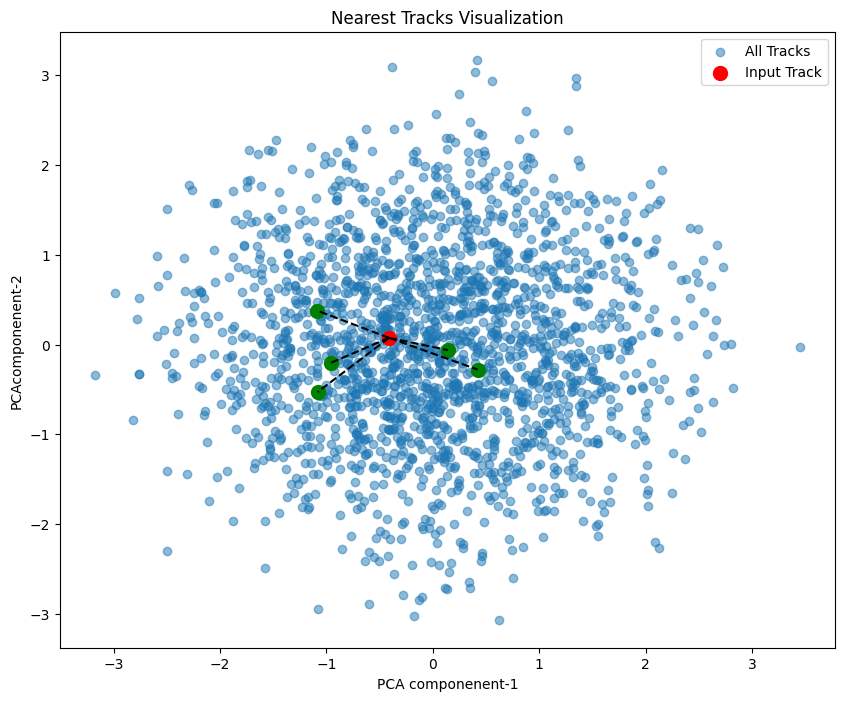

In [8]:
# Visualization using PCA
def plot_nearest_neighbors(track_number, k=5):
    """
    Plot the nearest neighbors for a given track number in 2D using PCA.
    """
    # Reduce dimensions for visualization
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(dataset_scaled[numeric_columns])

    # Find nearest tracks
    nearest_tracks = find_nearest_tracks(track_number, k)
    indices = nearest_tracks.index.tolist()

    # Plot all data points
    plt.figure(figsize=(10, 8))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, label="All Tracks")

    # Highlight the input track
    input_track_coords = reduced_data[track_number]
    plt.scatter(input_track_coords[0], input_track_coords[1], color='red', s=100, label="Input Track")

    # Highlight nearest neighbors
    for idx in indices:
        neighbor_coords = reduced_data[idx]
        plt.scatter(neighbor_coords[0], neighbor_coords[1], color='green', s=100)
        plt.plot([input_track_coords[0], neighbor_coords[0]], [input_track_coords[1], neighbor_coords[1]], 'k--')

    plt.title("Nearest Tracks Visualization")
    plt.xlabel("PCA componenent-1")
    plt.ylabel("PCAcomponenent-2")
    plt.legend()
    plt.show()
# Main program with user input
try:
    # Prompt the user for input
    track_number = int(input("Enter the track number to find the nearest neighbors: "))  # User inputs the track number
    k = int(input("Enter the k value (number of nearest neighbors): "))  # User inputs the k value

    # Validate track number and k value
    if 0 <= track_number < len(dataset) and k > 0:
        nearest_tracks = find_nearest_tracks(track_number, k)
        plot_nearest_neighbors(track_number, k)  # Display relevant columns
    else:
        print(f"Invalid track number or k value! Please enter a valid track number between 0 and {len(dataset) - 1}, and a positive k value.")
except ValueError:
    print("Invalid input! Please enter valid integers for the track number and k value.")
# Example Usage
#track_number = 56  # Replace with a valid track number
#k = 5  # Number of neighbors to find

# Plot nearest neighbors
#plot_nearest_neighbors(track_number, k)

### Track Recommendation using KNN:

In [9]:
# Recommendation Function
def recommend_tracks(track_number, k=5):
    """
    Recommend similar tracks based on a given track number.
    """
    # Validate the track_number
    if 0 <= track_number < len(dataset):
        return find_nearest_tracks(track_number, k)
    else:
        print(f"Track number {track_number} is out of range!")
        return pd.DataFrame()

# Main program with user input
try:
    # Prompt the user for input
    track_number = int(input("Enter the track number to find the nearest neighbors: "))  # User inputs the track number
    k = int(input("Enter the k value (number of nearest neighbors): "))  # User inputs the k value

    # Validate track number and k value
    if 0 <= track_number < len(dataset) and k > 0:
        print(f"\nFinding recommendations for track number: {track_number} with {k} nearest neighbors.")
        recommended_tracks = recommend_tracks(track_number, k)

        if not recommended_tracks.empty:
            print("\nRecommended Tracks:")
            print(recommended_tracks)  # Adjust columns as needed
        else:
            print("No tracks found for the given input.")
    else:
        print(f"Invalid track number or k value! Please enter a valid track number between 0 and {len(dataset) - 1}, and a positive k value.")
except ValueError:
    print("Invalid input! Please enter valid integers for the track number and k value.")

Enter the track number to find the nearest neighbors: 5
Enter the k value (number of nearest neighbors): 8

Finding recommendations for track number: 5 with 8 nearest neighbors.

Recommended Tracks:
      track_name     artist     album  danceability    energy   loudness  \
967    Track_968   Artist_2  Album_39      0.210793  0.643908 -56.617089   
732    Track_733  Artist_18  Album_39      0.466310  0.460355 -47.530570   
1312  Track_1313  Artist_92   Album_3      0.105874  0.718068 -41.017476   
762    Track_763  Artist_92   Album_5      0.217667  0.508959 -56.015679   
455    Track_456   Artist_8  Album_16      0.012157  0.847548 -59.985540   
491    Track_492   Artist_1  Album_11      0.403601  0.666686 -50.963343   
1182  Track_1183  Artist_86  Album_48      0.246659  0.677124 -54.745526   
1529  Track_1530  Artist_42  Album_17      0.233333  0.965518 -51.489336   

      speechiness  acousticness  instrumentalness  liveness   valence  \
967      0.395489      0.854565          0.

# Hyperparameter Tuning:

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the data
data = pd.read_csv(path+'/spotify_synthetic_data.csv')


In [31]:
# Display basic info
print(data.info())
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        2000 non-null   object 
 1   artist            2000 non-null   object 
 2   album             2000 non-null   object 
 3   danceability      2000 non-null   float64
 4   energy            2000 non-null   float64
 5   loudness          2000 non-null   float64
 6   speechiness       2000 non-null   float64
 7   acousticness      2000 non-null   float64
 8   instrumentalness  2000 non-null   float64
 9   liveness          2000 non-null   float64
 10  valence           2000 non-null   float64
 11  tempo             2000 non-null   float64
 12  genre             2000 non-null   object 
dtypes: float64(9), object(4)
memory usage: 203.2+ KB
None
Index(['track_name', 'artist', 'album', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumental

In [32]:
# Separate features and target
X = data.drop(['track_name', 'artist', 'album', 'genre'], axis=1)  # Exclude non-numeric and target columns
y = data['genre']  # Use 'genre' as the target


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the k-NN model
knn = KNeighborsClassifier()

# Define the parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform the search
grid_search.fit(X_train, y_train)

# Display the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {best_score:.2f}")

# Evaluate the best model on the test set
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.15
Test Set Accuracy: 0.14
